In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [55]:
#1. Read CSV File
data = pd.read_csv("kmean1.csv")

In [56]:
#2. Add Labels like A1, A2, A3, ...
data ['Label'] = ['a'+str(i+1) for i in range(len(data))]

In [57]:
#3. Extract features
X = data[['X', 'Y']]

In [58]:
#4. Apply K-Means
kmeans = KMeans(n_clusters = 2, random_state = 0)
kmeans.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=2, n_init=10, n_jobs=1, precompute_distances='auto',
    random_state=0, tol=0.0001, verbose=0)

In [59]:
#5. Get cluster labels
data['Cluster'] = kmeans.labels_
centroids = kmeans.cluster_centers_

In [60]:
#6. Print final clusters
clusters = data.groupby('Cluster')['Label'].apply(list)

In [61]:
for i in clusters.index:
    print(f"Cluster {i+1}:{', '.join(clusters[i])}")

Cluster 1:a5, a6
Cluster 2:a1, a2, a3, a4


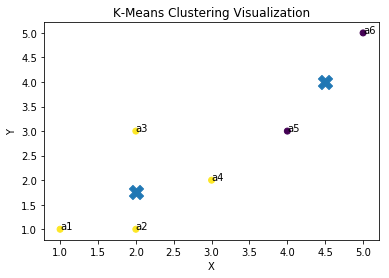

In [62]:
#7. Plot Clusters
plt.scatter(X['X'], X['Y'], c=data['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200)

#Annotate points with labels (a1, a2, ...)
for i in range(len(data)):
    plt.text(X.iloc[i,0], X.iloc[i,1], data['Label'][i])
    
plt.title("K-Means Clustering Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()